In [31]:
!pip install openpyxl gdown statsmodels -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats
from sklearn.linear_model import Lasso, Ridge, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import gdown
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA as StatsARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm

from pandas.api.types import is_numeric_dtype

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [32]:
# HELPER FUNCTIONS

def add_constant(X):
    if isinstance(X, pd.DataFrame):
        return pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)
    return np.column_stack([np.ones(len(X)), X])

def ols_fit(X, y):
    X_np = X.values if isinstance(X, pd.DataFrame) else np.asarray(X)
    y_np = y.values if isinstance(y, pd.Series) else np.asarray(y)
    XtX  = X_np.T @ X_np
    Xty  = X_np.T @ y_np
    try:
        beta = np.linalg.solve(XtX, Xty)
    except Exception:
        beta = np.linalg.pinv(XtX) @ Xty
    y_pred    = X_np @ beta
    residuals = y_np - y_pred
    n, k      = len(y_np), X_np.shape[1]
    rss  = np.sum(residuals**2)
    tss  = np.sum((y_np - y_np.mean())**2)
    r2   = 1 - rss/tss if tss > 0 else 0
    adj_r2 = 1 - (1-r2)*(n-1)/(n-k) if n > k else r2
    s2   = rss/(n-k)
    try:
        se = np.sqrt(np.diag(s2 * np.linalg.inv(XtX)))
    except Exception:
        se = np.sqrt(np.abs(np.diag(s2 * np.linalg.pinv(XtX))))
    t_stats  = beta / se
    p_values = 2*(1 - scipy_stats.t.cdf(np.abs(t_stats), n-k))
    f_stat   = (tss-rss)/(k-1) / (rss/(n-k)) if rss > 0 else np.inf
    f_pval   = 1 - scipy_stats.f.cdf(f_stat, k-1, n-k)
    return dict(coefficients=beta, predictions=y_pred, residuals=residuals,
                std_errors=se, t_stats=t_stats, p_values=p_values,
                r_squared=r2, adj_r_squared=adj_r2,
                f_stat=f_stat, f_pvalue=f_pval, n=n, k=k, rss=rss, tss=tss)

def durbin_watson_test(residuals):
    d = np.diff(residuals)
    return np.sum(d**2) / np.sum(residuals**2)

def breusch_pagan_test(residuals, X):
    n    = len(residuals)
    res  = ols_fit(X, residuals**2)
    stat = n * res['r_squared']
    pval = 1 - scipy_stats.chi2.cdf(stat, X.shape[1]-1)
    return stat, pval

def white_test(residuals, X):
    X      = np.asarray(X)
    X_sq   = X[:, 1:] ** 2
    X_aux  = np.column_stack([X, X_sq])
    n      = len(residuals)
    res    = ols_fit(X_aux, residuals**2)
    stat   = n * res['r_squared']
    df     = X_aux.shape[1] - 1
    pval   = 1 - scipy_stats.chi2.cdf(stat, df)
    return stat, pval

def breusch_godfrey_test(residuals, X, nlags=1):
    n = len(residuals)
    lag_mat = np.zeros((n-nlags, nlags))
    for i in range(nlags):
        lag_mat[:, i] = residuals[nlags-i-1:n-i-1]
    X_aug = np.column_stack([X[nlags:], lag_mat])
    res   = ols_fit(X_aug, residuals[nlags:])
    stat  = (n-nlags) * res['r_squared']
    pval  = 1 - scipy_stats.chi2.cdf(stat, nlags)
    return stat, pval

def jarque_bera_test(residuals):
    n    = len(residuals)
    sk   = scipy_stats.skew(residuals)
    ku   = scipy_stats.kurtosis(residuals, fisher=False)
    stat = (n/6)*(sk**2 + (ku-3)**2/4)
    pval = 1 - scipy_stats.chi2.cdf(stat, 2)
    return stat, pval, sk, ku

def calculate_vif(X):
    vifs = []
    for i in range(X.shape[1]):
        X_o = np.delete(X, i, axis=1)
        if X_o.shape[1] == 0:
            vifs.append(1.0); continue
        r2 = ols_fit(X_o, X[:, i])['r_squared']
        vifs.append(1/(1-r2) if r2 < 0.999 else 999)
    return np.array(vifs)

def acf_function(x, nlags=40):
    x  = np.asarray(x).squeeze() - np.mean(x)
    c0 = np.dot(x, x)/len(x)
    out = np.ones(nlags+1)
    for k in range(1, nlags+1):
        out[k] = np.dot(x[:-k], x[k:])/(len(x)*c0)
    return out

def pacf_function(x, nlags=40):
    acf = acf_function(x, nlags)
    p   = np.zeros(nlags+1); p[0] = 1
    if nlags > 0: p[1] = acf[1]
    for k in range(2, nlags+1):
        num = acf[k] - sum(p[j]*acf[k-j] for j in range(1,k))
        den = 1       - sum(p[j]*acf[j]   for j in range(1,k))
        p[k] = num/den if abs(den) > 1e-10 else 0
    return p

In [33]:
FILE_ID   = '1XIwyGtm3KSkQG3jZdYhjOiL4yojOeZOP'
file_path = 'data.xlsx'
gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', file_path, quiet=True)

industry_m = pd.read_excel(file_path, sheet_name='Industry_M')
macro_m    = pd.read_excel(file_path, sheet_name='Macro_M')
stock_m    = pd.read_excel(file_path, sheet_name='StockPrices_M')

for df in [industry_m, macro_m, stock_m]:
    df.columns = df.columns.str.strip()
    df['Date'] = pd.to_datetime(df['Date'])
    df['YearMonth'] = df['Date'].dt.to_period('M')

df_monthly = (industry_m
              .merge(macro_m, on='YearMonth', how='outer', suffixes=('', '_drop'))
              .merge(stock_m, on='YearMonth', how='outer', suffixes=('', '_drop2')))

df_monthly['Date'] = df_monthly['YearMonth'].dt.to_timestamp()

cols_to_remove = [c for c in df_monthly.columns if 'YearMonth' in c or '_drop' in c]
df_monthly = df_monthly.drop(columns=cols_to_remove)

df_monthly = (df_monthly
              .sort_values('Date')
              .reset_index(drop=True)
              .drop_duplicates(subset='Date', keep='first'))

df_monthly['Spread'] = df_monthly['CL2'] - df_monthly['CL1']

if 'Shell' in df_monthly.columns:
    df_monthly = df_monthly.drop(columns=['Shell'])

df_monthly['Target_Next_Spread'] = df_monthly['Spread'].shift(-1)
df_clean = df_monthly.ffill(limit=2).dropna()
len(df_monthly)

355

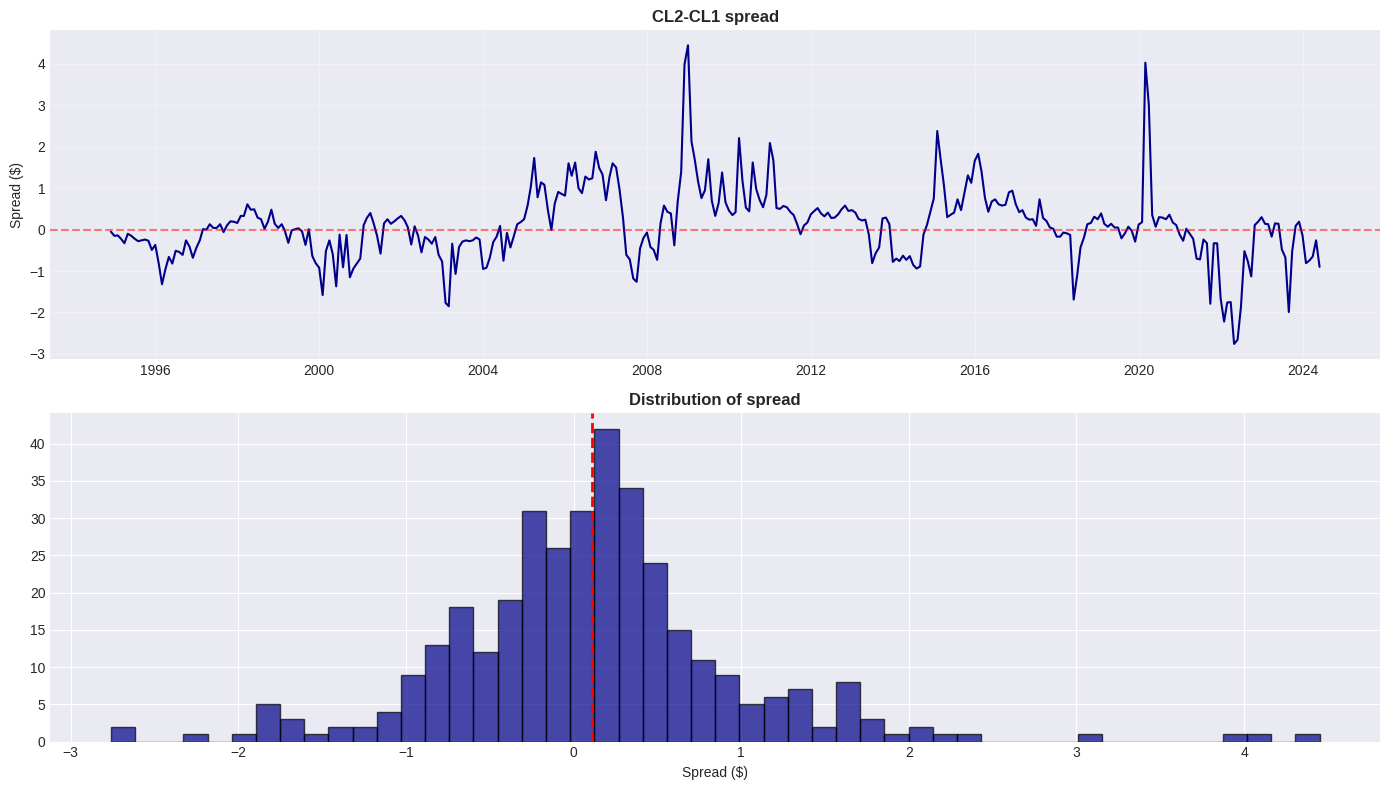

In [34]:
# EXPLORATORY ANALYSIS

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(df_clean['Date'], df_clean['Spread'], lw=1.5, color='darkblue')
axes[0].axhline(0, color='red', ls='--', alpha=0.5)
axes[0].set_title('CL2-CL1 spread', fontweight='bold')
axes[0].set_ylabel('Spread ($)'); axes[0].grid(True, alpha=0.3)

axes[1].hist(df_clean['Spread'], bins=50, edgecolor='black', alpha=0.7, color='darkblue')
axes[1].axvline(df_clean['Spread'].mean(), color='red', ls='--', lw=2)
axes[1].set_title('Distribution of spread', fontweight='bold')
axes[1].set_xlabel('Spread ($)')
plt.tight_layout(); plt.show()


In [35]:
# STATIONARITY TESTS

print('-'*80)
print('STATIONARITY TESTS (ADF) - RAW DATA')
print('-'*80)

test_vars = ['Spread','CL1','CL2','Brent','3M Yield','10Y Yield','SPX','VIX']
test_vars = [v for v in test_vars if v in df_clean.columns]

rows = []
for v in test_vars:
    r = adfuller(df_clean[v].dropna(), autolag='AIC')
    rows.append({'Variable': v, 'ADF Stat': round(r[0],4),
                 'p-value': round(r[1],4), 'Lags': r[2]})
print(pd.DataFrame(rows).to_string(index=False))

print('\n' + '-'*80)
print('STATIONARITY TESTS — RETURNS / CHANGES')
print('-'*80)

for v in ['CL1','CL2','Brent','SPX']:
    if v in df_clean.columns:
        df_clean[f'{v}_return'] = df_clean[v].pct_change()
for v in ['3M Yield','10Y Yield']:
    if v in df_clean.columns:
        df_clean[f'{v}_change'] = df_clean[v].diff()

ret_vars = ['CL1_return','CL2_return','Brent_return','SPX_return',
            '3M Yield_change','10Y Yield_change']
ret_vars = [v for v in ret_vars if v in df_clean.columns]

rows2 = []
for v in ret_vars:
    s = df_clean[v].dropna()
    if len(s) > 10:
        r = adfuller(s, autolag='AIC')
        rows2.append({'Variable': v, 'ADF Stat': round(r[0],4),
                      'p-value': round(r[1],4), 'Lags': r[2]})
print(pd.DataFrame(rows2).to_string(index=False))


--------------------------------------------------------------------------------
STATIONARITY TESTS (ADF) - RAW DATA
--------------------------------------------------------------------------------
 Variable  ADF Stat  p-value  Lags
   Spread   -4.4569   0.0002     3
      CL1   -2.4144   0.1377     1
      CL2   -2.3449   0.1579     1
    Brent   -2.2593   0.1854     1
 3M Yield   -2.7863   0.0603     8
10Y Yield   -2.3189   0.1659     2
      SPX    2.1544   0.9988    16
      VIX   -6.1803   0.0000     0

--------------------------------------------------------------------------------
STATIONARITY TESTS — RETURNS / CHANGES
--------------------------------------------------------------------------------
        Variable  ADF Stat  p-value  Lags
      CL1_return  -10.8324   0.0000     3
      CL2_return  -10.5292   0.0000     3
    Brent_return  -16.1822   0.0000     0
      SPX_return  -18.6127   0.0000     0
 3M Yield_change   -3.7186   0.0039     7
10Y Yield_change  -14.0700   0.00

In [36]:
# FEATURE ENGINEERING

df_features = df_clean.copy()

for lag in range(1, 4):
    df_features[f'Spread_lag{lag}'] = df_features['Spread'].shift(lag)

for v in ['CL1','Brent','3M Yield','10Y Yield','SPX','VIX']:
    if v in df_features.columns:
        df_features[f'{v}_lag1'] = df_features[v].shift(1)

for v in ['CL1','CL2','Brent','SPX']:
    if v in df_features.columns:
        df_features[f'{v}_return'] = df_features[v].pct_change()
        df_features[f'{v}_change'] = df_features[v].diff()

for v in ['3M Yield','10Y Yield']:
    if v in df_features.columns:
        df_features[f'{v}_change'] = df_features[v].diff()

if '10Y Yield' in df_features.columns and '3M Yield' in df_features.columns:
    df_features['Yield_Spread'] = df_features['10Y Yield'] - df_features['3M Yield']

df_features = df_features.dropna()
print(f'{len(df_features)} observations, {len(df_features.columns)} columns')

352 observations, 48 columns


In [37]:
# TRAIN / TEST SPLIT

df_model = df_features.copy()
df_model['Target_Next_Spread'] = df_model['Spread'].shift(-1)
df_model = df_model.dropna()

split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx].copy()
test_df  = df_model.iloc[split_idx:].copy()

exclude_cols = ['Target_Next_Spread', 'Date']
feature_cols = [c for c in df_model.columns if c not in exclude_cols]

X_train = df_model[feature_cols].iloc[:split_idx].copy()
X_test  = df_model[feature_cols].iloc[split_idx:].copy()

y_train = df_model['Target_Next_Spread'].iloc[:split_idx].copy()
y_test  = df_model['Target_Next_Spread'].iloc[split_idx:].copy()

test_dates = df_model['Date'].iloc[split_idx:].values

print(f"Values: train = {len(X_train)}, test = {len(X_test)}")

Values: train = 280, test = 71


--------------------------------------------------------------------------------
OLS REGRESSION
--------------------------------------------------------------------------------


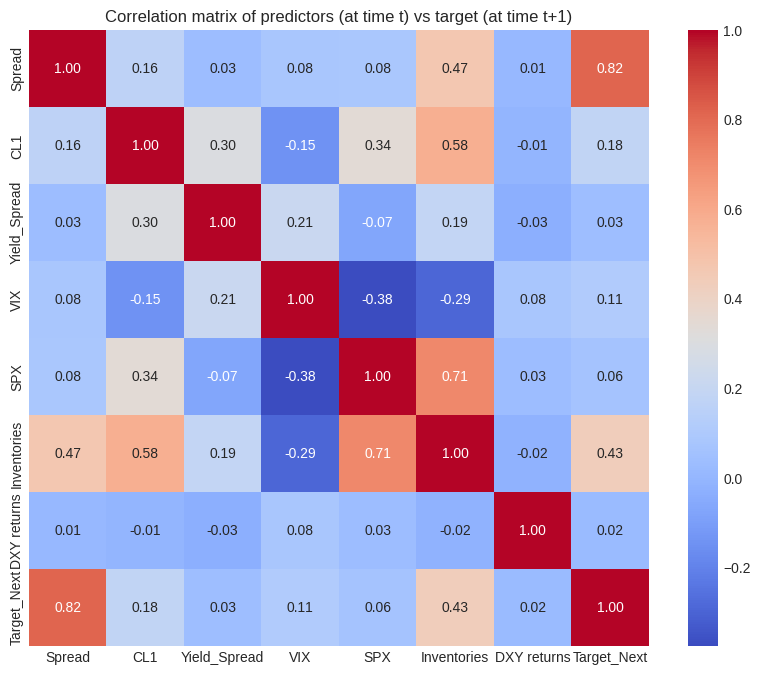


OLS R squared = 0.6815  Adj R squared = 0.6733  F = 83.14 (p = 1.11e-16)
    Variable  Coefficient  OLS Std Err    t-stat  p-value
       const    -1.369562 4.658402e-01 -2.939983 0.003564
      Spread     0.726492 4.548008e-02 15.973842 0.000000
         CL1     0.000299 1.199906e-03  0.249059 0.803503
Yield_Spread    -0.041393 2.941165e-02 -1.407356 0.160464
         VIX     0.008806 4.110021e-03  2.142458 0.033044
         SPX    -0.000197 9.510718e-05 -2.076460 0.038790
 Inventories     0.000002 5.826060e-07  2.745560 0.006443
 DXY returns     0.325007 1.230130e+00  0.264205 0.791822
    Variable  Coefficient  HAC Std Err  t-stat (HAC)  p-val (HAC)
       const    -1.369562 5.147555e-01     -2.660607 7.799983e-03
      Spread     0.726492 4.605014e-02     15.776099 4.544164e-56
         CL1     0.000299 8.620972e-04      0.346652 7.288531e-01
Yield_Spread    -0.041393 3.088916e-02     -1.340039 1.802328e-01
         VIX     0.008806 8.354052e-03      1.054045 2.918623e-01
        

In [38]:
# OLS

print('-'*80)
print('OLS REGRESSION')
print('-'*80)

ols_features = ['Spread', 'CL1', 'Yield_Spread', 'VIX', 'SPX', 'Inventories', 'DXY returns']
ols_features = [f for f in ols_features if f in X_train.columns]

X_train_ols = X_train[ols_features].copy()
y_train_ols = y_train.copy()
X_test_ols  = X_test[ols_features].copy()
y_test_ols  = y_test.copy()

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_ols.assign(Target_Next=y_train_ols).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation matrix of predictors (at time t) vs target (at time t+1)')
plt.show()

X_train_const = add_constant(X_train_ols)
X_test_const  = add_constant(X_test_ols)

result_dict = ols_fit(X_train_const, y_train_ols)

print(f'\nOLS R squared = {result_dict["r_squared"]:.4f}  '
      f'Adj R squared = {result_dict["adj_r_squared"]:.4f}  '
      f'F = {result_dict["f_stat"]:.2f} (p = {result_dict["f_pvalue"]:.2e})')

coef_df = pd.DataFrame({'Variable': ['const'] + ols_features,
    'Coefficient': result_dict['coefficients'],
    'OLS Std Err': result_dict['std_errors'],
    't-stat': result_dict['t_stats'],
    'p-value': result_dict['p_values'],})
print(coef_df.to_string(index=False))

import statsmodels.api as sm
sm_model = sm.OLS(y_train_ols, X_train_const).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

hac_df = pd.DataFrame({
    'Variable': ['const'] + ols_features,
    'Coefficient': sm_model.params.values,
    'HAC Std Err': sm_model.bse.values,
    't-stat (HAC)': sm_model.tvalues.values,
    'p-val (HAC)': sm_model.pvalues.values,})
print(hac_df.to_string(index=False))

vif_df = pd.DataFrame({
    'Feature': X_train_ols.columns, 'VIF': calculate_vif(X_train_ols.values)}).sort_values('VIF', ascending=False)
print(vif_df.to_string(index=False))

print('\n' + '-'*80)
print('DIAGNOSTIC TESTS — OLS')
print('-'*80)

residuals     = result_dict['residuals']
X_arr_const   = np.asarray(X_train_const)

bp_stat, bp_p = breusch_pagan_test(residuals, X_arr_const)
wh_stat, wh_p = white_test(residuals, X_arr_const)
dw            = durbin_watson_test(residuals)
bg_stat, bg_p = breusch_godfrey_test(residuals, X_arr_const, nlags=5)
jb_stat, jb_p, jb_sk, jb_ku = jarque_bera_test(residuals)

print(f'Breusch-Pagan: LM = {bp_stat:.4f} p = {bp_p:.4f}')
print(f'White Test: LM = {wh_stat:.4f} p = {wh_p:.4f}')
print(f'Durbin-Watson: {dw:.4f}')
print(f'Breusch-Godfrey: LM = {bg_stat:.4f} p = {bg_p:.4f}')
print(f'Jarque-Bera: JB = {jb_stat:.4f} p = {jb_p:.4f}')
print(f'Skewness = {jb_sk:.4f} Kurtosis = {jb_ku:.4f}')

# OOS performance
y_test_pred_ols  = X_test_const.values @ result_dict['coefficients']
y_train_pred_ols = result_dict['predictions']

test_rmse_ols = np.sqrt(mean_squared_error(y_test_ols, y_test_pred_ols))
test_r2_ols = r2_score(y_test_ols, y_test_pred_ols)

print(f'\nIn-Sample  RMSE = {np.sqrt(mean_squared_error(y_train_ols,y_train_pred_ols)):.4f}  '
      f'R squared = {result_dict["r_squared"]:.4f}')
print(f'OOS RMSE = {test_rmse_ols:.4f}  R squared = {test_r2_ols:.4f}')

# Chow
print('\n' + '-'*80)
print('CHOW TEST')
print('-'*80)

n_obs   = len(y_train_ols)
bp_idx  = n_obs // 2
X_arr   = np.asarray(X_train_const)
y_arr   = y_train_ols.values

r1 = ols_fit(X_arr[:bp_idx], y_arr[:bp_idx])
r2 = ols_fit(X_arr[bp_idx:], y_arr[bp_idx:])

rss_u   = r1['rss'] + r2['rss']
rss_r   = result_dict['rss']
k_chow  = result_dict['k']

chow_f  = (rss_r - rss_u)/k_chow / (rss_u/(n_obs - 2*k_chow))
chow_p  = 1 - scipy_stats.f.cdf(chow_f, k_chow, n_obs - 2*k_chow)

mid_dt  = train_df['Date'].iloc[bp_idx].strftime('%Y-%m')
print(f'Chow F-stat = {chow_f:.4f}  p = {chow_p:.4f}')

# Ramsey RESET test
print('\n' + '-'*80)
print('RESET TEST')
print('-'*80)

yh = result_dict['predictions']
X_aug = np.column_stack([X_arr, yh**2, yh**3])
r_aug = ols_fit(X_aug, y_train_ols)

rf = (rss_r - r_aug['rss'])/2 / (r_aug['rss']/(n_obs - r_aug['k']))
rp = 1 - scipy_stats.f.cdf(rf, 2, n_obs - r_aug['k'])

print(f'RESET F-stat = {rf:.4f}  p = {rp:.4f}')

--------------------------------------------------------------------------------
ARIMA
--------------------------------------------------------------------------------


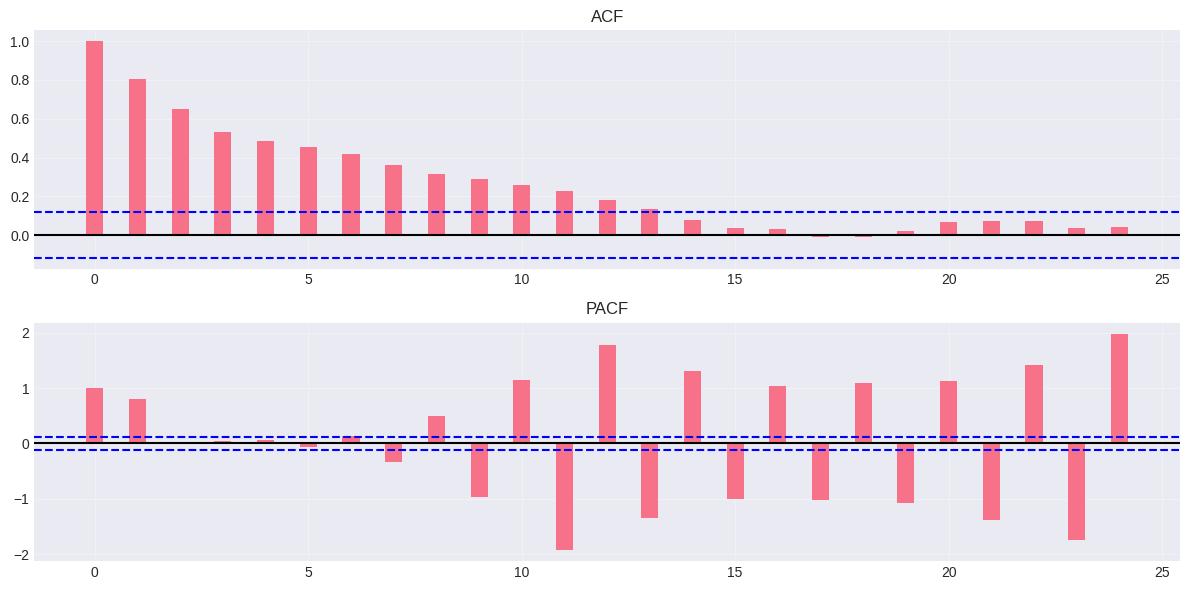


Top 10 ARIMA models by AIC:
    order     AIC
(1, 0, 0) 380.999
(1, 0, 3) 381.138
(1, 1, 1) 381.943
(1, 0, 1) 382.581
(2, 0, 0) 382.615
(2, 0, 3) 383.073
(1, 1, 2) 383.210
(2, 1, 1) 383.241
(3, 0, 2) 383.321
(2, 0, 2) 383.814

Best order: ARIMA(1, 0, 0)  AIC = 380.999
In-Sample RMSE = 0.4721
OOS RMSE = 1.0906
Ljung-Box p = 0.5915


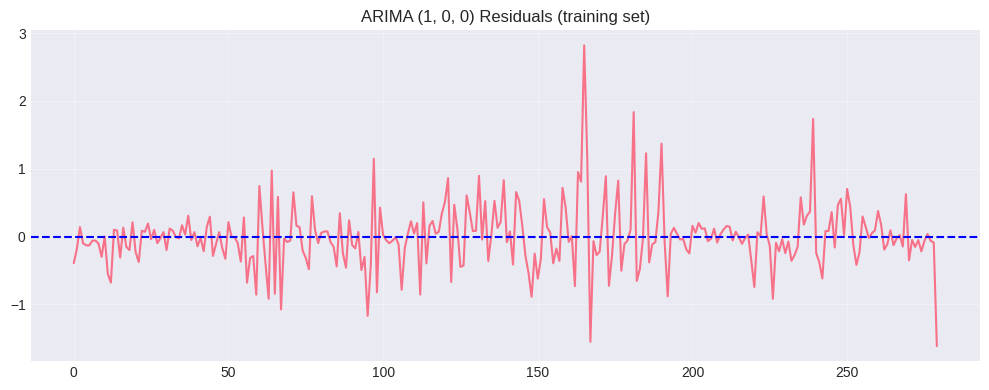

                               SARIMAX Results                                
Dep. Variable:                 Spread   No. Observations:                  280
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -187.499
Date:                Wed, 18 Feb 2026   AIC                            380.999
Time:                        14:51:54   BIC                            391.903
Sample:                             0   HQIC                           385.373
                                - 280                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1705      0.173      0.985      0.325      -0.169       0.510
ar.L1          0.8203      0.022     36.692      0.000       0.776       0.864
sigma2         0.2225      0.010     21.919      0.0

In [39]:
# ARIMA

print('-'*80)
print('ARIMA')
print('-'*80)

y_train_arima = train_df['Spread'].copy().reset_index(drop=True)
y_test_arima  = test_df['Spread'].copy().reset_index(drop=True)

# ACF / PACF plots
conf = 1.96 / np.sqrt(len(y_train_arima))
acf_v  = acf_function(y_train_arima, nlags=24)
pacf_v = pacf_function(y_train_arima, nlags=24)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
for ax, vals, title in zip(axes, [acf_v, pacf_v], ['ACF','PACF']):
    ax.bar(range(len(vals)), vals, width=0.4)
    ax.axhline(0, color='black')
    ax.axhline( conf, color='blue', ls='--')
    ax.axhline(-conf, color='blue', ls='--')
    ax.set_title(title); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_aic = np.inf
best_order = (1, 0, 0)
best_arima = None
arima_rows = []

for p in range(4):
    for d in range(2):
        for q in range(4):
            try:
                mdl = StatsARIMA(y_train_arima, order=(p, d, q)).fit()
                arima_rows.append({'order': str((p,d,q)), 'AIC': round(mdl.aic, 3)})
                if mdl.aic < best_aic:
                    best_aic   = mdl.aic
                    best_order = (p, d, q)
                    best_arima = mdl
            except Exception:
                pass

arima_results_df = pd.DataFrame(arima_rows).sort_values(by='AIC')
print("\nTop 10 ARIMA models by AIC:")
print(arima_results_df.head(10).to_string(index=False))

print(f'\nBest order: ARIMA{best_order}  AIC = {best_aic:.3f}')

y_train_pred_arima = best_arima.fittedvalues.values

all_forecasts = best_arima.forecast(steps=len(y_test) + 1).values
y_test_pred_arima = all_forecasts[1:]

min_len = min(len(y_train_arima), len(y_train_pred_arima))
train_rmse_arima = np.sqrt(mean_squared_error(
    y_train_arima.values[-min_len:], y_train_pred_arima[-min_len:]))
test_rmse_arima = np.sqrt(mean_squared_error(y_test, y_test_pred_arima))
print(f'In-Sample RMSE = {train_rmse_arima:.4f}')
print(f'OOS RMSE = {test_rmse_arima:.4f}')

# Ljung-Box
lb = acorr_ljungbox(best_arima.resid.dropna(), lags=[10], return_df=True)
print(f'Ljung-Box p = {lb["lb_pvalue"].values[0]:.4f}')

plt.figure(figsize=(10, 4))
plt.plot(best_arima.resid.values)
plt.title(f'ARIMA {best_order} Residuals (training set)')
plt.axhline(0, color='blue', ls='--'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(best_arima.summary())

In [40]:
# ARIMAX

print('-'*80)
print('ARIMAX')
print('-'*80)

exog_vars   = ['CL1', 'Brent', '3M Yield', 'VIX', 'Inventories']
exog_vars   = [v for v in exog_vars if v in train_df.columns]
arima_order = best_order

train_ax = train_df[['Spread', 'Target_Next_Spread'] + exog_vars].copy()
for lag in range(1, arima_order[0]+1):
    train_ax[f'Spread_AR{lag}'] = train_ax['Spread'].shift(lag)
train_ax = train_ax.dropna()

ar_cols  = [f'Spread_AR{i}' for i in range(1, arima_order[0]+1)]
all_cols = ar_cols + exog_vars

X_train_ax = train_ax[all_cols]
y_train_ax = train_ax['Target_Next_Spread']

tail_cols = ['Spread', 'Target_Next_Spread'] + exog_vars
test_ext = pd.concat(
    [train_df[tail_cols].tail(max(arima_order[0], 1)), test_df[tail_cols]],
    ignore_index=True)
for lag in range(1, arima_order[0]+1):
    test_ext[f'Spread_AR{lag}'] = test_ext['Spread'].shift(lag)
test_ext    = test_ext.iloc[max(arima_order[0],1):].reset_index(drop=True)

X_test_ax = test_ext[all_cols]
y_test_ax = test_ext['Target_Next_Spread']

X_train_ax_c = add_constant(X_train_ax)
X_test_ax_c  = add_constant(X_test_ax)

res_ax = ols_fit(X_train_ax_c, y_train_ax)
print(f'\nARIMAX R squared = {res_ax["r_squared"]:.4f}')

coef_ax = pd.DataFrame({
    'Feature': ['const'] + all_cols,
    'Coefficient': res_ax['coefficients'],
    'p-value': res_ax['p_values'],})
print('\nCoefficients:')
print(coef_ax.to_string(index=False))

y_test_pred_arimax = X_test_ax_c.values @ res_ax['coefficients']
test_rmse_arimax   = np.sqrt(mean_squared_error(y_test_ax, y_test_pred_arimax))
print(f'\nOOS RMSE: {test_rmse_arimax:.4f}')

--------------------------------------------------------------------------------
ARIMAX
--------------------------------------------------------------------------------

ARIMAX R squared = 0.4646

Coefficients:
    Feature  Coefficient  p-value
      const    -2.109128 0.003362
 Spread_AR1     0.549273 0.000000
        CL1     0.014667 0.094357
      Brent    -0.013867 0.082100
   3M Yield     0.008956 0.738068
        VIX     0.014792 0.008809
Inventories     0.000002 0.003191

OOS RMSE: 0.9366


--------------------------------------------------------------------------------
LASSO
--------------------------------------------------------------------------------


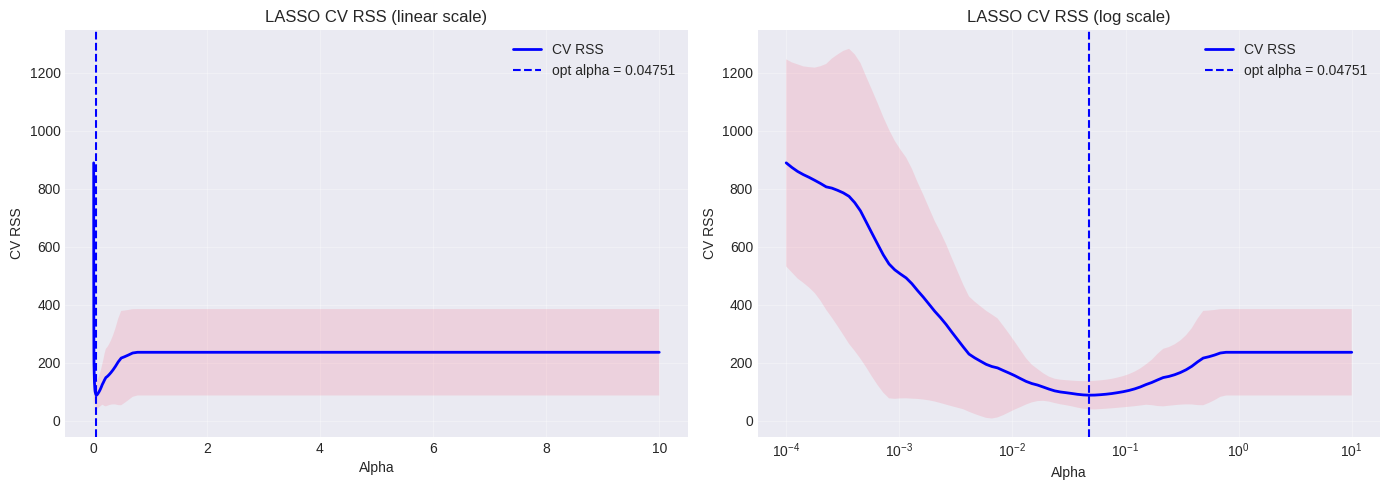

Optimal alpha: 0.047508

Selected 6 features:
     Feature      Coef
      Spread  0.593603
    VIX_lag1  0.029228
 Spread_lag3  0.020283
 Inventories  0.020048
   Rig Count  0.017090
Brent_change -0.000094

OOS: RMSE = 0.7189  and R squared = 0.4647


In [41]:
# LASSO

print('-'*80)
print('LASSO')
print('-'*80)

exclude_cols = ['Date', 'Target_Next_Spread', 'CL2']

feature_cols = [c for c in train_df.columns if c not in exclude_cols and is_numeric_dtype(train_df[c])]

X_tr_l = X_train[feature_cols].copy()
X_te_l = X_test[feature_cols].copy()
y_tr_l = y_train.copy()
y_te_l = y_test.copy()

valid_f = [c for c in feature_cols
           if X_tr_l[c].notna().all() and X_tr_l[c].std() > 1e-10]

X_tr_l = X_tr_l[valid_f]
X_te_l = X_te_l[valid_f]
scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_tr_l)
Xte_sc = scaler.transform(X_te_l)
Xtr_sc = pd.DataFrame(Xtr_sc, columns=valid_f, index=X_tr_l.index)
Xte_sc = pd.DataFrame(Xte_sc, columns=valid_f, index=X_te_l.index)
tscv = TimeSeriesSplit(n_splits=5)
alphas = np.logspace(-4, 1, 100)
lasso_cv = LassoCV(alphas=alphas, cv=tscv, random_state=42, max_iter=10000)
lasso_cv.fit(Xtr_sc, y_tr_l)
n_s = len(y_tr_l)
m_mse = lasso_cv.mse_path_.mean(axis=1)
s_mse = lasso_cv.mse_path_.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xsc in zip(axes, ['linear','log']):
    ax.plot(lasso_cv.alphas_, m_mse*n_s, 'b-', lw=2, label='CV RSS')
    ax.fill_between(lasso_cv.alphas_,
                    (m_mse-s_mse)*n_s, (m_mse+s_mse)*n_s, alpha=0.2)
    ax.axvline(lasso_cv.alpha_, color='blue', ls='--',
               label=f'opt alpha = {lasso_cv.alpha_:.5f}')
    ax.set_xlabel('Alpha'); ax.set_ylabel('CV RSS')
    ax.set_title(f'LASSO CV RSS ({xsc} scale)')
    ax.set_xscale(xsc); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Optimal alpha: {lasso_cv.alpha_:.6f}')

lasso_m = Lasso(alpha=lasso_cv.alpha_, random_state=42, max_iter=10000)
lasso_m.fit(Xtr_sc, y_tr_l)

coef_l = (pd.DataFrame({'Feature': valid_f, 'Coef': lasso_m.coef_})
          .query('Coef != 0')
          .sort_values('Coef', key=abs, ascending=False))

print(f'\nSelected {len(coef_l)} features:')
print(coef_l.head(15).to_string(index=False))

y_test_pred_lasso = lasso_m.predict(Xte_sc)
test_rmse_lasso   = np.sqrt(mean_squared_error(y_te_l, y_test_pred_lasso))
test_r2_lasso     = r2_score(y_te_l, y_test_pred_lasso)

print(f'\nOOS: RMSE = {test_rmse_lasso:.4f}  and R squared = {test_r2_lasso:.4f}')

--------------------------------------------------------------------------------
RIDGE
--------------------------------------------------------------------------------


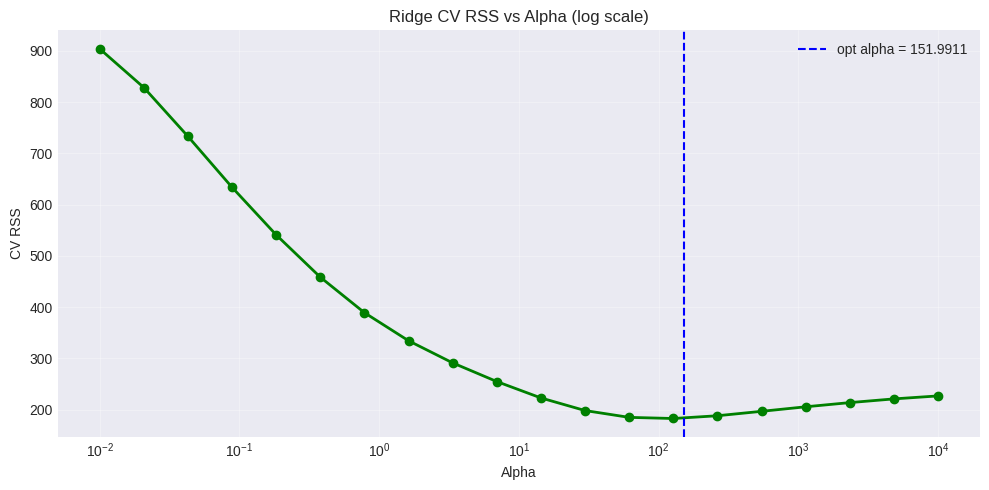

Optimal alpha: 151.991108
         Feature      Coef
          Spread  0.273127
     Spread_lag1  0.107430
     Inventories  0.084849
     Spread_lag3  0.049968
        VIX_lag1  0.049238
       Rig Count  0.046727
Daily Production -0.042759
  CRKS321C Index -0.040809
      CL1_return -0.038472
   TotalEnergies  0.037966
    Yield_Spread -0.035977
     Spread_lag2  0.035757
       10Y Yield -0.034556
  10Y Yield_lag1 -0.034385
       CPI YOY % -0.034122

OOS: RMSE = 0.7542 and R squared = 0.4108


In [42]:
# RIDGE

print('-'*80)
print('RIDGE')
print('-'*80)

alphas_r = np.logspace(-2, 4, 100)
ridge_cv = RidgeCV(alphas=alphas_r, cv=tscv)
ridge_cv.fit(Xtr_sc, y_tr_l)

sub_a = np.logspace(-2, 4, 20)
sub_mse = [-cross_val_score(Ridge(alpha=a), Xtr_sc, y_tr_l, cv=tscv, scoring='neg_mean_squared_error').mean() for a in sub_a]

plt.figure(figsize=(10, 5))
plt.plot(sub_a, np.array(sub_mse)*n_s, 'go-', lw=2)
plt.axvline(ridge_cv.alpha_, color='blue', ls='--',
            label=f'opt alpha = {ridge_cv.alpha_:.4f}')
plt.xlabel('Alpha'); plt.ylabel('CV RSS')
plt.title('Ridge CV RSS vs Alpha (log scale)')
plt.xscale('log'); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Optimal alpha: {ridge_cv.alpha_:.6f}')

ridge_m = Ridge(alpha=ridge_cv.alpha_)
ridge_m.fit(Xtr_sc, y_tr_l)

coef_r = (pd.DataFrame({'Feature': valid_f, 'Coef': ridge_m.coef_}).sort_values('Coef', key=abs, ascending=False))
print(coef_r.head(15).to_string(index=False))

y_test_pred_ridge = ridge_m.predict(Xte_sc)
test_rmse_ridge   = np.sqrt(mean_squared_error(y_te_l, y_test_pred_ridge))
test_r2_ridge     = r2_score(y_te_l, y_test_pred_ridge)
print(f'\nOOS: RMSE = {test_rmse_ridge:.4f} and R squared = {test_r2_ridge:.4f}')


In [43]:
# MODEL COMPARISON

print('-'*80)
print('MODEL COMPARISON')
print('-'*80)

naive_fc = np.full(len(y_test), train_df['Spread'].iloc[-1])
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_fc))

comparison = pd.DataFrame({'Model': ['LASSO', 'OLS', 'Ridge', 'ARIMAX', 'ARIMA', 'Naive'], 'Test RMSE': [test_rmse_lasso, test_rmse_ols, test_rmse_ridge, test_rmse_arimax, test_rmse_arima, naive_rmse]}).sort_values('Test RMSE').reset_index(drop=True)
print(comparison.to_string(index=False))


--------------------------------------------------------------------------------
MODEL COMPARISON
--------------------------------------------------------------------------------
 Model  Test RMSE
 LASSO   0.718936
 Ridge   0.754239
   OLS   0.775376
ARIMAX   0.936566
 ARIMA   1.090598
 Naive   1.736094


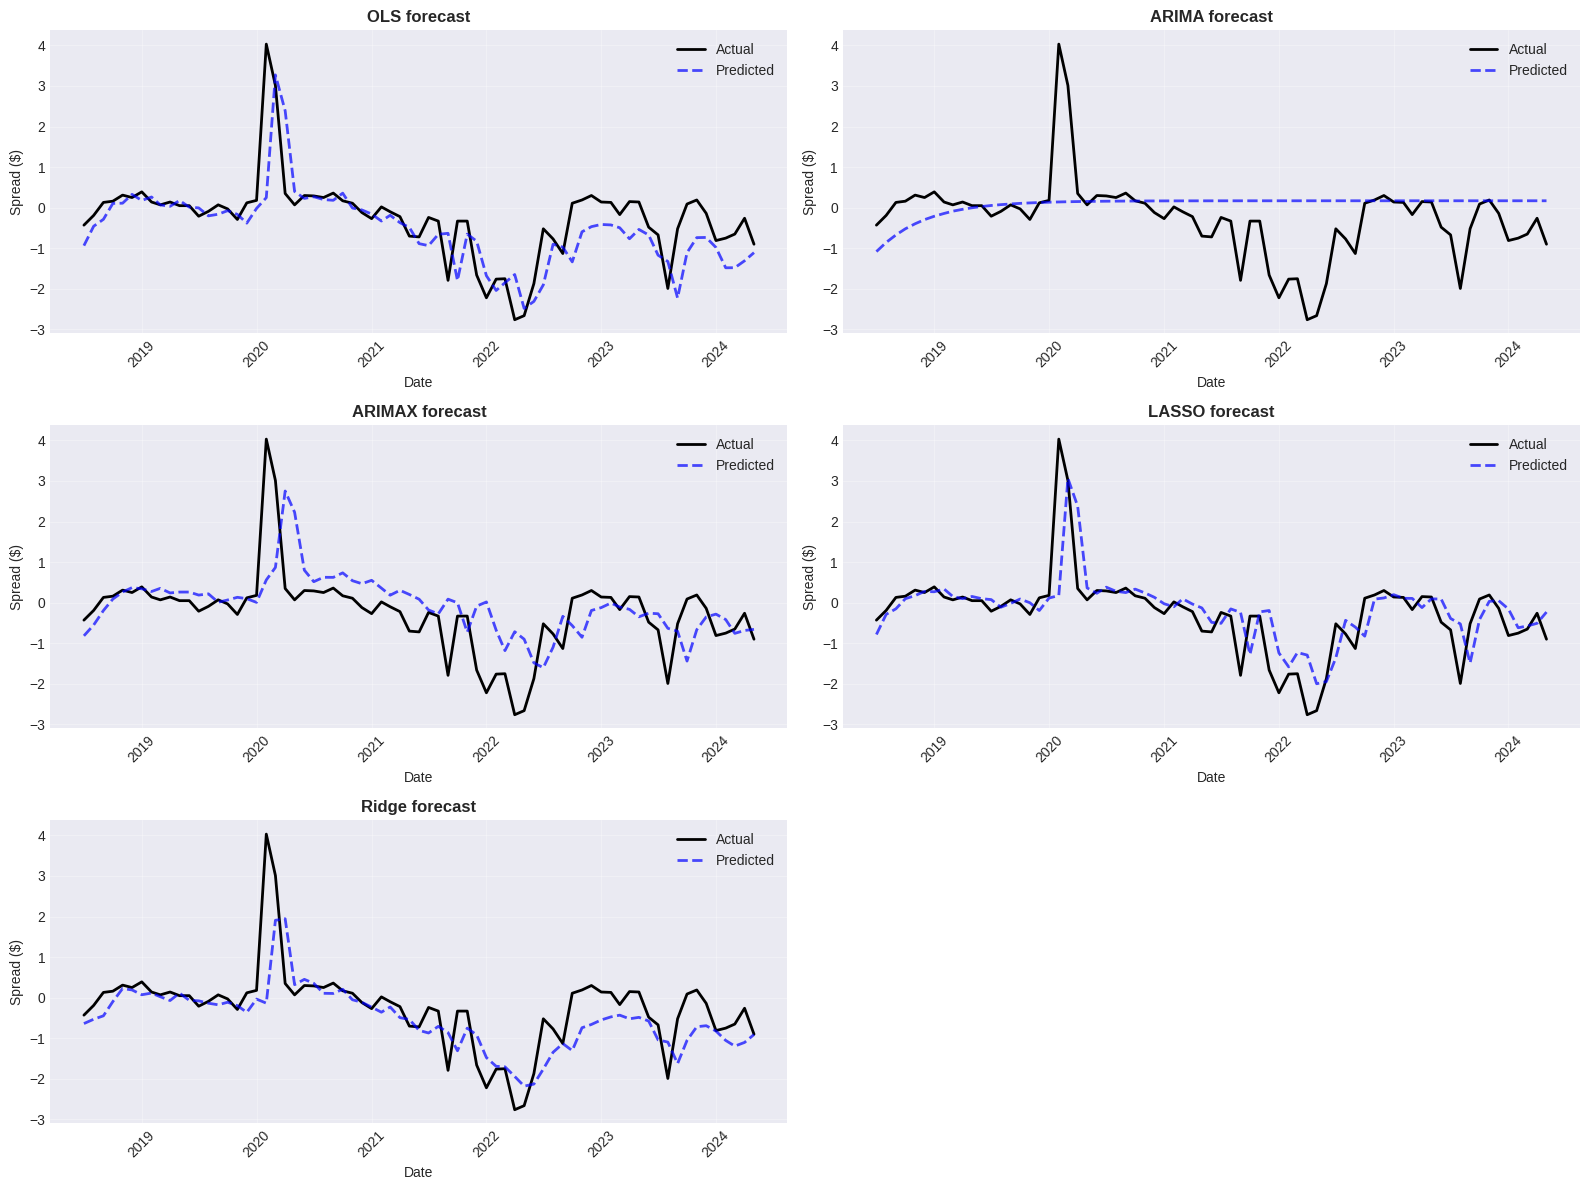

In [44]:
# GRAPHS

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()
test_dates = test_df['Date'].values
y_test_actual = test_df['Target_Next_Spread'].values

models_plot = [('OLS', y_test_pred_ols), ('ARIMA', y_test_pred_arima), ('ARIMAX', y_test_pred_arimax), ('LASSO', y_test_pred_lasso), ('Ridge', y_test_pred_ridge),]
for i, (name, pred) in enumerate(models_plot):
    axes[i].plot(test_dates, y_test_actual, label='Actual', lw=2, color='black')
    axes[i].plot(test_dates, pred, label='Predicted', lw=2, color='blue', ls='--', alpha=0.7)
    axes[i].set_title(f'{name} forecast', fontweight='bold')
    axes[i].set_xlabel('Date'); axes[i].set_ylabel('Spread ($)')
    axes[i].legend(); axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', rotation=45)
axes[5].axis('off')
plt.tight_layout(); plt.show()

--------------------------------------------------------------------------------
TRADING STRATEGY
--------------------------------------------------------------------------------

Gross (no fees)
 Model  Cost  Total P&L  Sharpe  Win Rate  Trades
   OLS   0.0       9.39  0.5949     56.34      31
 LASSO   0.0       4.19  0.2623     54.93      33
 Ridge   0.0      12.31  0.7884     64.79      31
 ARIMA   0.0       0.63  0.0393     52.11      21
ARIMAX   0.0      10.37  0.6592     50.70      47

Net (0.1$ per trade)
 Model  Cost  Total P&L  Sharpe  Win Rate  Trades
   OLS   0.1       6.29  0.3970     53.52      31
 LASSO   0.1       0.89  0.0553     46.48      33
 Ridge   0.1       9.21  0.5893     57.75      31
 ARIMA   0.1      -1.47 -0.0895     50.70      21
ARIMAX   0.1       5.67  0.3543     43.66      47


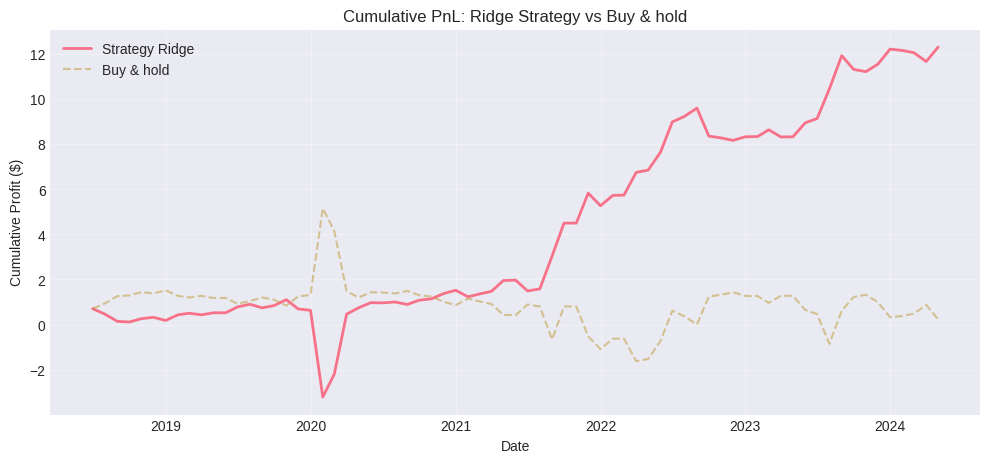

In [45]:
# TRADING STRATEGY

print('-'*80)
print('TRADING STRATEGY')
print('-'*80)

def trading_strategy(df_test, preds, name, cost=0.0):
    d = df_test.copy().reset_index(drop=True)
    d['Pred'] = np.asarray(preds)
    d['Signal'] = np.where(d['Pred'] > d['Spread'], 1, -1)
    price_move = d['Target_Next_Spread'] - d['Spread']
    d['Gross_PnL'] = d['Signal'] * price_move
    prev_signal = np.concatenate(([0], d['Signal'].values[:-1]))
    d['Trade_Legs'] = np.abs(d['Signal'] - prev_signal)
    d['Net_PnL'] = d['Gross_PnL'] - (d['Trade_Legs'] * cost)

    total_pnl = d['Net_PnL'].sum()
    mean = d['Net_PnL'].mean()
    std = d['Net_PnL'].std()

    sharpe = (mean / std * np.sqrt(12)) if std > 0 else 0
    win_rate = (d['Net_PnL'] > 0).mean() * 100
    nb_trades = d['Trade_Legs'].sum()

    return {'Model': name, 'Cost': cost,'Total P&L': round(total_pnl, 4), 'Sharpe': round(sharpe, 4), 'Win Rate': round(win_rate, 2), 'Trades': int(nb_trades)}

models_s = [('OLS', y_test_pred_ols), ('LASSO', y_test_pred_lasso), ('Ridge', y_test_pred_ridge), ('ARIMA', y_test_pred_arima), ('ARIMAX', y_test_pred_arimax)]

rows_s = []
for nm, pr in models_s:
    for c in [0.0, 0.1]:
        rows_s.append(trading_strategy(test_df, pr, nm, cost=c))

disp_cols = ['Model', 'Cost', 'Total P&L', 'Sharpe', 'Win Rate', 'Trades']
res_trading = pd.DataFrame(rows_s)

print("\nGross (no fees)")
print(res_trading[res_trading['Cost']==0.0][disp_cols].to_string(index=False))

print("\nNet (0.1$ per trade)")
print(res_trading[res_trading['Cost']==0.1][disp_cols].to_string(index=False))

best_model_name = "Ridge"
d_plot = test_df.copy().reset_index(drop=True)
d_plot['Pred'] = y_test_pred_ridge
d_plot['Signal'] = np.where(d_plot['Pred'] > d_plot['Spread'], 1, -1)
price_move = d_plot['Target_Next_Spread'] - d_plot['Spread']
d_plot['PnL'] = d_plot['Signal'] * price_move
d_plot['Cumulative PnL'] = d_plot['PnL'].cumsum()

plt.figure(figsize=(12, 5))
plt.plot(test_dates, d_plot['Cumulative PnL'], lw=2, label=f'Strategy {best_model_name}')
plt.plot(test_dates, (d_plot['Target_Next_Spread'] - d_plot['Spread']).cumsum(),
         ls='--', alpha=0.5, label='Buy & hold')
plt.title(f'Cumulative PnL: {best_model_name} Strategy vs Buy & hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Profit ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()